In [1]:
## IMPORTS 
import os
import sys 
current_dir = os.getcwd()
LOCSCALE_2_SCRIPTS_PATH = os.path.dirname(current_dir)
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy import stats
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import plot_correlations
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist


random.seed(42)
np.random.seed(42)

PLOT_DATA_STORE_PATH = setup_environment(current_dir)

Data downloaded and extracted successfully.
Sourcing data from: /home/abharadwaj1/thesis/publications/notebooks/LocScale2.0_NComms_2026_plotData
--------------------------------------------------------------------------------


## Supplementary 6 b

In [2]:
all_fsc_curves_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_b_fsc_curves_data.csv")

all_fsc_curves_data = pd.read_csv(all_fsc_curves_csv)

/tmp/ipykernel_31034/2346599379.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(new_xticklabels);


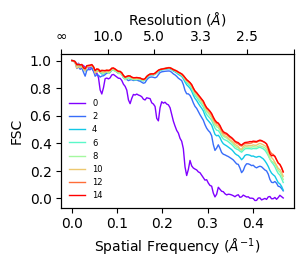

In [3]:
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=all_fsc_curves_data, x="frequency", y="fsc", hue="epoch", palette="rainbow", ax=ax, legend="full", lw=1)
ax.set_xlabel("Spatial Frequency ($Å^{-1}$)")
ax.set_ylabel("FSC")
ax.legend(fontsize=6, frameon=False)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4]);
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]);
ax1 = ax.twiny()
ax1.set_xlabel("Resolution ($Å$)")
new_xticklabels = ['{:.1f}'.format(1/x) if x != 0 else '∞' for x in ax.get_xticks()];
ax1.set_xticklabels(new_xticklabels);



## Supplementary 6 c

In [4]:
loss_data_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_c_loss_curve_data.csv")

loss_data = pd.read_csv(loss_data_csv)

Text(0, 0.5, 'Loss')

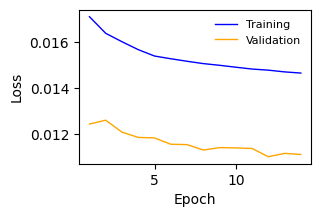

In [5]:
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=loss_data, x="epoch", y="loss", hue="type", palette={"Training": "blue", "Validation": "orange"}, ax=ax, legend="full", lw=1)
ax.legend(fontsize=8, frameon=False)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

## Supplementary 6 d

In [6]:
fsc_curve_data_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_d_fsc_curve_data_guinier_wilson.csv")
fsc_curve_data = pd.read_csv(fsc_curve_data_csv)

In [7]:
def calculate_significance(data_1, data_2):
    """
    Calculates the significance of the difference between the mean of the list of data and the mean of the first element of the list of data
    """
    from scipy.stats import permutation_test
    def statistic(data1, data2):
        return np.mean(data1) - np.mean(data2)
    n_resamples = 10000

    permutation_test_result = permutation_test((data_1, data_2), statistic=statistic, n_resamples=n_resamples)
    
    pvalue = permutation_test_result.pvalue
    return pvalue

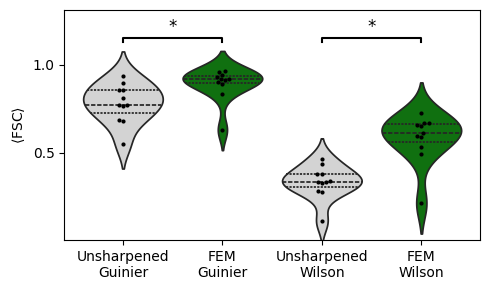

In [8]:
palette = {"1_Unsharpened_Guinier": "lightgrey", "2_FEM_Guinier": "green", "3_Unsharpened_Wilson": "lightgrey", "4_FEM_Wilson": "green"}
fig, ax = plt.subplots(figsize=(5,3))
sns.violinplot(data=fsc_curve_data, x="type", y="mean_fsc", hue="type", inner="quartile", 
                palette=palette, order=["1_Unsharpened_Guinier", "2_FEM_Guinier", "3_Unsharpened_Wilson", "4_FEM_Wilson"], ax=ax)
sns.swarmplot(data=fsc_curve_data, x="type", y="mean_fsc", color="black", \
                order=["1_Unsharpened_Guinier", "2_FEM_Guinier", "3_Unsharpened_Wilson", "4_FEM_Wilson"], ax=ax, size=3)
ax.set_xlabel("")
ax.set_ylabel("$\\langle$FSC$\\rangle$")
ax.set_xticks([0, 1, 2, 3], labels=["Unsharpened\nGuinier", "FEM\nGuinier", "Unsharpened\nWilson", "FEM\nWilson"]);
# add statistical significance
data_1 = fsc_curve_data[fsc_curve_data["type"] == "1_Unsharpened_Guinier"]["mean_fsc"].values
data_2 = fsc_curve_data[fsc_curve_data["type"] == "2_FEM_Guinier"]["mean_fsc"].values
data_3 = fsc_curve_data[fsc_curve_data["type"] == "3_Unsharpened_Wilson"]["mean_fsc"].values
data_4 = fsc_curve_data[fsc_curve_data["type"] == "4_FEM_Wilson"]["mean_fsc"].values
pvalue_1_2 = calculate_significance(data_1, data_2)
pvalue_3_4 = calculate_significance(data_3, data_4)

pvalue_1_2_text = "*" if pvalue_1_2 < 0.05 else "n.s."
pvalue_3_4_text = "*" if pvalue_3_4 < 0.05 else "n.s."

# add lines for significance
y_max = fsc_curve_data["mean_fsc"].max() + 0.15
ax.plot([0, 0, 1, 1], [y_max+0.02, y_max+0.04, y_max+0.04, y_max+0.02], color="black")
ax.text(0.5, y_max+0.05, pvalue_1_2_text, ha="center", va="bottom", color="black", fontsize=12)
ax.plot([2, 2, 3, 3], [y_max+0.02, y_max+0.04, y_max+0.04, y_max+0.02], color="black")
ax.text(2.5, y_max+0.05, pvalue_3_4_text, ha="center", va="bottom", color="black", fontsize=12)
ax.set_ylim(0, y_max+0.2)
ax.set_yticks([0.5, 1])
#ax.get_legend().remove()
plt.tight_layout()


#### The monte carlo samples are drawn randomly from the same cube. Due to challenges involved in sampling the cubes reproducibly, the cubes present in this repository are not the exact same cubes used to reproduce the figures in the manuscript. However, the general conclusion remains the same. This applies to Supplementary 6 e, f and g. 

## Supplementary 2 e

In [9]:
from locscale.include.emmer.ndimage.map_utils import load_map
monte_carlo_samples_paths = [
    os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "monte_carlo_sample_3.mrc"),
    os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "monte_carlo_sample_7.mrc"),
    os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "monte_carlo_sample_10.mrc"),
    os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "monte_carlo_sample_14.mrc"),
]

voxel_data_json_path = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "histogram_data.json")


slice_index_to_plot = 8
voxel_to_highlight = (9, 26, slice_index_to_plot)
monte_carlo_samples = [load_map(m)[0] for m in monte_carlo_samples_paths]

slices_to_plot = [cube[:, :, slice_index_to_plot] for cube in monte_carlo_samples]

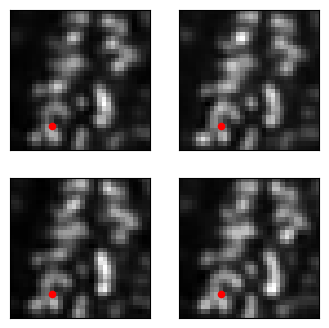

In [10]:

fig, ax = plt.subplots(2, 2, figsize=(4,4))
for i in range(2):
    for j in range(2):
        idx = i*2 + j
        im = ax[i, j].imshow(slices_to_plot[idx], cmap="gray")
        ax[i, j].scatter(voxel_to_highlight[0], voxel_to_highlight[1], color="red", s=20)
        ax[i, j].set_xticks([]);
        ax[i, j].set_yticks([]);

<Axes: ylabel='Count'>

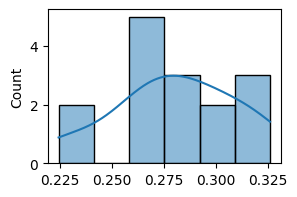

In [11]:
voxel_intensities = pd.read_json(voxel_data_json_path)[:15]
fig, ax = plt.subplots(1, 1, figsize=(3,2))
sns.histplot(voxel_intensities, bins=6, kde=True, legend=False, ax=ax)

## Supplementary 6 f

In [12]:
mean_map_path = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "mean_map_num_samples_15.mrc")
p_values_map_path = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "p_values_map_num_samples_15.mrc")
significant_deviations_map_path = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "significant_deviations_map_num_samples_15.mrc")

mean_map, apix = load_map(mean_map_path)
p_values_map, apix = load_map(p_values_map_path)
significant_deviations_map, apix = load_map(significant_deviations_map_path)
num_subplots = 4

indices = np.linspace(0, 31, num_subplots, dtype=int)
mean_map_slices = [mean_map[:, :, i] for i in indices]
p_values_map_slices = [p_values_map[:, :, i] for i in indices]
significant_deviations_map_slices = [significant_deviations_map[:, :, i] for i in indices]

mean_map_slices = np.array(mean_map_slices)
p_values_map_slices = np.array(p_values_map_slices)
significant_deviations_map_slices = np.array(significant_deviations_map_slices)

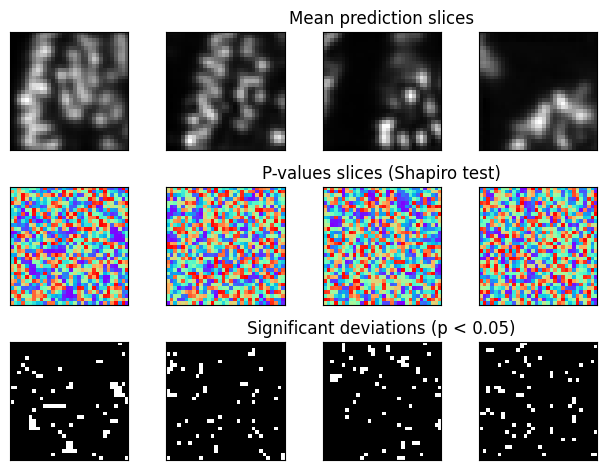

In [13]:
fig, ax = plt.subplots(3, num_subplots)
for i, index in enumerate(indices):
    # plot the X cube slice in first two, p value in second and significance in third
    ax[0,i].imshow(mean_map[:,:, index], cmap='gray')
    ax[0,i].set_xticks([])
    ax[0,i].set_yticks([])
    if i == 2:
        ax[0,i].set_title("Mean prediction slices")
    
    ax[1,i].imshow(p_values_map[:, :, index], cmap='rainbow')
    ax[1,i].set_xticks([])
    ax[1,i].set_yticks([])
    if i == 2:
        ax[1,i].set_title("P-values slices (Shapiro test)")

    ax[2,i].imshow(significant_deviations_map[:, :, index], cmap='gray')
    ax[2,i].set_xticks([])
    ax[2,i].set_yticks([])
    if i == 2:
        ax[2,i].set_title("Significant deviations (p < 0.05)")
plt.tight_layout()

Text(0, 0.5, 'Count')

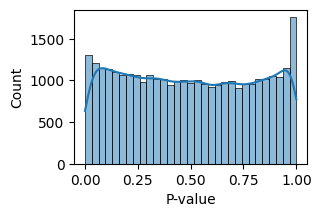

In [14]:
p_values_array = p_values_map.flatten()
fig, ax = plt.subplots(1, 1, figsize=(3,2))
sns.histplot(p_values_array, bins=31, kde=True, legend=False, ax=ax)
ax.set_xlabel("P-value")
ax.set_ylabel("Count")


## Supplementary 6 g

In [15]:
means_evolution_json = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "list_of_means500.json")
variance_evolution_json = os.path.join(PLOT_DATA_STORE_PATH, "monte_carlo_samples", "list_of_variances500.json")

means_evolution = pd.read_json(means_evolution_json).T
variance_evolution = pd.read_json(variance_evolution_json).T


In [16]:
means_evolution_diff = means_evolution.diff(axis=0).dropna().reset_index()
variance_evolution_diff = variance_evolution.diff(axis=0).dropna().reset_index()

means_evolution_diff.head()

,index,0,1,2,3,4,5,6,7,8,...,490,491,492,493,494,495,496,497,498,499
0,1,0.000475,-0.000153,-0.000191,-0.000079,-0.000053,0.000064,0.000246,0.000334,-0.017742,...,0.000905,0.001483,-0.000249,-0.000837,-0.000152,0.001868,-3.926243e-04,-0.000328,-0.000786,-0.000226
1,2,0.001183,0.000035,0.000036,0.000044,0.000239,-0.000110,-0.010691,-0.000094,0.006525,...,-0.000302,0.000050,-0.000005,-0.000337,0.000612,0.003997,2.220669e-04,0.000084,0.000354,-0.000047
2,3,-0.000231,0.000028,-0.000018,-0.000034,-0.000070,-0.000102,-0.004156,0.000124,0.000771,...,0.000186,-0.000144,-0.000027,0.000056,0.000732,0.000520,-1.318184e-05,0.000159,0.000145,-0.000001
3,4,0.000311,-0.000015,-0.000031,0.000079,0.000043,-0.000034,-0.002409,-0.000053,-0.000391,...,0.000091,0.000011,-0.000102,0.000179,-0.000521,0.001086,-7.494700e-07,0.000008,0.000186,0.000002
4,5,-0.000042,-0.000025,-0.000032,-0.000013,-0.000059,0.000037,0.004558,-0.000003,-0.002021,...,-0.000121,-0.000047,-0.000070,-0.000298,0.000703,-0.001554,1.843984e-04,0.000050,-0.000162,-0.000004


In [17]:
columns = ["MC_sample"] + [f"cycle_{i}" for i in range(500)]
means_evolution_diff.columns = columns
variance_evolution_diff.columns = columns
means_evolution_melted = means_evolution_diff.melt(id_vars=["MC_sample"], var_name="cycle", value_name="mean")
variance_evolution_melted = variance_evolution_diff.melt(id_vars=["MC_sample"], var_name="cycle", value_name="variance")
means_evolution_melted.head()


,MC_sample,cycle,mean
0,1,cycle_0,0.000475
1,2,cycle_0,0.001183
2,3,cycle_0,-0.000231
3,4,cycle_0,0.000311
4,5,cycle_0,-0.000042


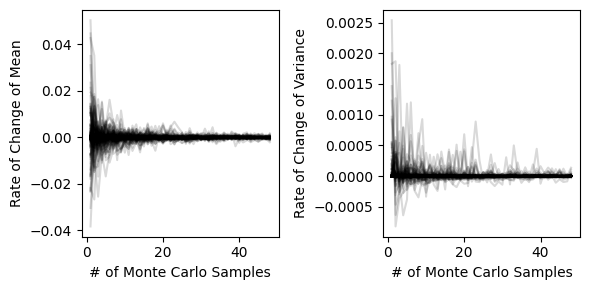

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(6,3)) 
sns.lineplot(data=means_evolution_melted, x="MC_sample", y="mean", units="cycle", color="black", alpha=0.15, legend=False, ax=ax[0], estimator=None)
ax[0].set_xlabel("# of Monte Carlo Samples")
ax[0].set_ylabel("Rate of Change of Mean")
sns.lineplot(data=variance_evolution_melted, x="MC_sample", y="variance", units="cycle", color="black", alpha=0.15, legend=False, ax=ax[1], estimator=None)
ax[1].set_xlabel("# of Monte Carlo Samples")
ax[1].set_ylabel("Rate of Change of Variance")
plt.tight_layout()


## Supplementary 6 h 

### The data points used to calibrate the isotonic regressor in Supplementary Figure 6h was randomly split into training and testing. The exact split used in this repository varied from the one used to generate the figure in the manuscript. 

In [19]:

uncalibrated_csv_path = os.path.join(PLOT_DATA_STORE_PATH, "s6_h_residuals_uncalibrated_data.csv")
calibrated_csv_path = os.path.join(PLOT_DATA_STORE_PATH, "s6_h_residuals_calibrated_data.csv")


residual_data_uncalibrated = pd.read_csv(uncalibrated_csv_path)
residual_data_calibrated = pd.read_csv(calibrated_csv_path)

calibration_plot_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_i_calibration_curve_data.csv")
calibration_plot_df = pd.read_csv(calibration_plot_csv)


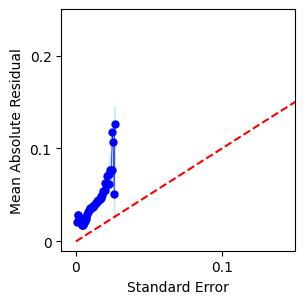

Uncertainty Calibration Error (UCE): 0.01980836017500268
Maximum Calibration Error (MCE): 0.01980836017500268
Unweighted Calibration Error: 0.03303526717905681


In [20]:
from scripts.utils.plot_utils import plot_binned_residuals_2
plot_binned_residuals_2(residual_data_uncalibrated["standard_deviation"].values, \
                        residual_data_uncalibrated["absolute_residual"].values, \
                        50, xlabel="Standard Error", ylabel="Mean Absolute Residual", \
                        linewidth=0.5, marker=".", markersize=10);


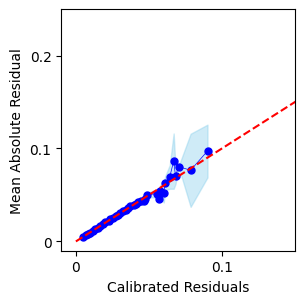

Uncertainty Calibration Error (UCE): 5.012280978394535e-05
Maximum Calibration Error (MCE): 9.163138119377711e-06
Unweighted Calibration Error: 0.0021896110028839445


In [21]:
plot_binned_residuals_2(residual_data_calibrated["standard_deviation"].values, \
                        residual_data_calibrated["absolute_residual"].values, \
                        50, xlabel="Calibrated Residuals", ylabel="Mean Absolute Residual", \
                        linewidth=0.5, marker=".", markersize=10);


(-0.01, 0.11)

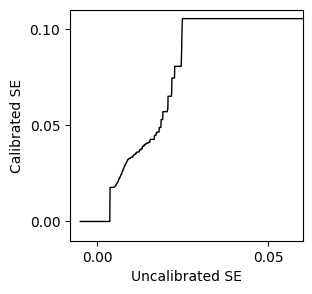

In [22]:
plt.figure(figsize=(3,3))
sns.lineplot(data=calibration_plot_df, x="uncalibrated_standard_error", y="calibrated_standard_error", color="black", lw=1)
plt.xlabel("Uncalibrated SE")
plt.ylabel("Calibrated SE")
plt.xticks([0, 0.05])
plt.yticks([0, 0.05, 0.1])
plt.xlim(-0.008, 0.06)
plt.ylim(-0.01, 0.11)

## Supplementary 6 k

In [23]:

phase_correlation_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_k_phase_correlation_data.csv")
phase_correlation_df = pd.read_csv(phase_correlation_csv)


Text(0, 0.5, 'Phase Correlation')

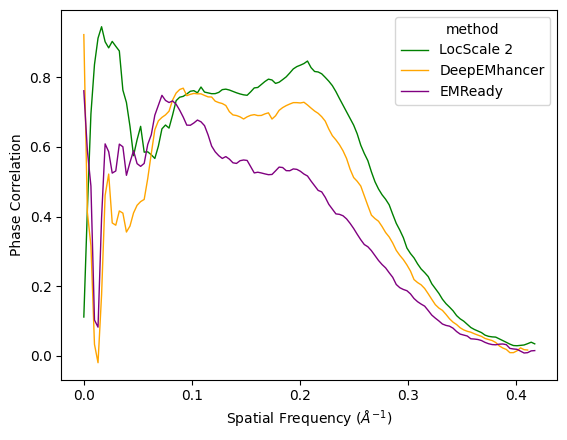

In [24]:
sns.lineplot(data=phase_correlation_df, 
             x="frequency", y="phase_correlation", hue="method", 
             palette={"LocScale 2": "green", "DeepEMhancer": "orange", "EMReady": "purple"}, lw=1)
#plt.ylim(, 1.05)
plt.xlabel("Spatial Frequency ($Å^{-1}$)")
plt.ylabel("Phase Correlation")

## Supplementary 6 l, 6 m

In [25]:

res_dict = {"0026" : 6.3, "0038" : 3.2, "0071" : 3.9, "0093" : 3.4, "0094" : 3.4, "0132" : 3.9, "0234" : 3.3, "0408" : 3.2, "0415" : 3.1, "4288" : 4.4, "0452" : 3.7, "0490" : 7.8, "0492" : 7.7, "0567" : 3.67, "0589" : 3.9, "0592" : 3.15, "0665" : 3.9, "0776" : 2.67, "10049" : 3.3, "10069" : 3.2, "10100" : 4.15, "10105" : 4.1, "10106" : 3.5, "10273" : 4.3, "10279" : 3.33, "10324" : 3.1, "10333" : 3.2, "10418" : 2.96, "10534" : 3.4, "10585" : 3.7, "10595" : 3.25, "10617" : 3.8, "20145" : 3.3, "20146" : 4.2, "20189" : 4.3, "20234" : 3.8, "20249" : 3.2, "20254" : 3.6, "20259" : 3.57, "20270" : 4, "20271" : 4.1, "20352" : 7.8, "20521" : 2.1, "20986" : 4.1, "21012" : 3.8, "21107" : 3.07, "21144" : 3.1, "21391" : 3.5, "3661" : 5.16, "3662" : 5.16, "3802" : 4.4, "3885" : 6.1, "3908" : 3.55, "4032" : 4.35, "4073" : 3.55, "4074" : 4.3, "4079" : 4.15, "4148" : 4, "4162" : 4.1, "4192" : 3.81, "4214" : 3.4, "4241" : 4.1, "4272" : 4.3, "4401" : 3.35, "4404" : 3.93, "4429" : 4.4, "4588" : 3.6, "4589" : 3.7, "4593" : 3.7, "4728" : 4.8, "4746" : 3.47, "4759" : 3.8, "4888" : 2.8, "4889" : 2.9, "4890" : 3.1, "4907" : 3.2, "4917" : 3.9, "4918" : 4.5, "4941" : 4, "4983" : 3.5, "7009" : 3.7, "7041" : 3.7, "7065" : 6.5, "7090" : 6.5, "7334" : 3.9, "7335" : 3.5, "8911" : 3.7, "8958" : 3.7, "8960" : 3.7, "9258" : 3.6, "9259" : 3.9, "9931" : 3.3, "9934" : 3.22, "9935" : 3.08, "9939" : 2.83, "9941" : 2.95, "9695" : 3.64, "0193" : 4.3, "0257" : 3.7, "0264" : 4.6, "0499" : 2.7, "10401" : 3.77, "20449" : 2.88, "20849" : 3.77, "4611" : 3.2, "4646" : 4.34, "4733" : 3.65, "4789" : 3.2, "7133" : 3.1, "7882" : 3.32, "8069" : 4.04, "9112" : 3.1, "9298" : 4.5, "9374" : 3.5, "0282" : 3.26, "0311" : 4.2, "0560" : 3.2, "10365" : 3.1, "20220" : 3.5, "20226" : 3.2, "3545" : 5.9, "4141" : 6.7, "4531" : 2.83, "4571" : 3.3, "4997" : 3.96, "7127" : 4.1, "7573" : 3.2, "8702" : 3.55, "9610" : 3.5}


In [26]:
from matplotlib import cm
from matplotlib.colors import Normalize
cmap = cm.rainbow
test_emdb_ids = ['0282','0311','10365','20220','20226','3545','4571','4997','7127','8702','9610']
res_values_for_analysis = np.array([res_dict[emdb_id] for emdb_id in test_emdb_ids])
norm = Normalize(vmin=np.min(res_values_for_analysis), vmax=np.max(res_values_for_analysis))
palette = {int(emdb_id): cmap(norm(res)) for emdb_id, res in res_dict.items()}

In [27]:
amplitude_correlations_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_L_amplitude_correlations_data.csv")
# amplitude_correlations_data.to_csv(amplitude_correlations_csv, index=True)
phase_correlations_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_M_phase_correlations_data.csv")
# phase_correlations_data.to_csv(phase_correlations_csv, index=True)
amplitude_correlations_data = pd.read_csv(amplitude_correlations_csv)
phase_correlations_data = pd.read_csv(phase_correlations_csv)

# sort by resolution
amplitude_correlations_data = amplitude_correlations_data.sort_values(by="resolution")
phase_correlations_data = phase_correlations_data.sort_values(by="resolution")

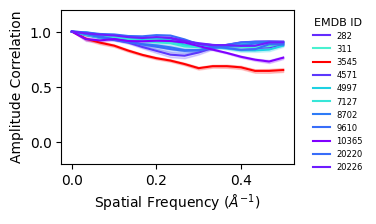

In [28]:
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=amplitude_correlations_data, \
             x="frequency", y="amplitude_correlation", \
            hue="emdb_id", palette=palette, \
            errorbar=("ci", 95), ax=ax)
ax.set_xlabel("Spatial Frequency ($Å^{-1}$)")
ax.set_ylabel("Amplitude Correlation")
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 0.5, 1.0]);
ax.set_xticks([0, 0.2, 0.4]);
# put the legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title="EMDB ID", title_fontsize=8, frameon=False)



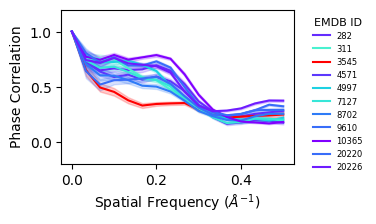

In [29]:
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=phase_correlations_data, \
             x="frequency", y="phase_correlation", \
            hue="emdb_id", palette=palette, \
            errorbar=("ci", 95), ax=ax)
ax.set_xlabel("Spatial Frequency ($Å^{-1}$)")
ax.set_ylabel("Phase Correlation")
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 0.5, 1.0]);
ax.set_xticks([0, 0.2, 0.4]);
# put the legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title="EMDB ID", title_fontsize=8, frameon=False)


# Supplementary 6 n

In [30]:
variance_correlations_scatter_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_N_variance_correlation_scatter.csv")
scatter_df = pd.read_csv(variance_correlations_scatter_csv)

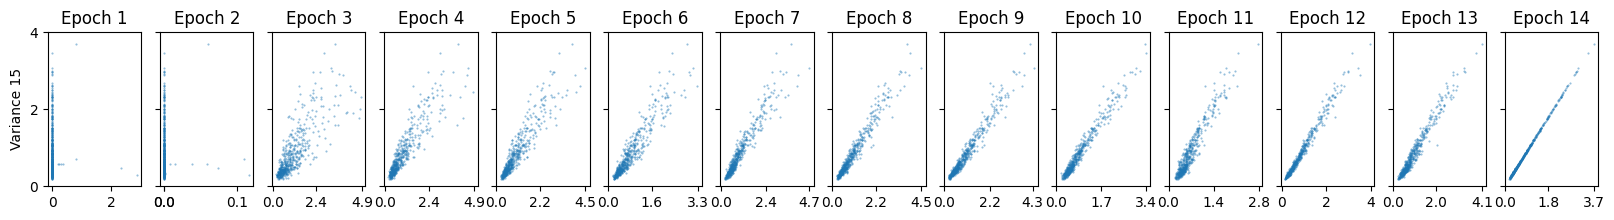

In [31]:
fig, axes = plt.subplots(1, 14, figsize=(20, 2))
epochs = sorted(scatter_df["epoch"].unique())
for i, epoch in enumerate(epochs):
    ax = axes[i]
    epoch_data = scatter_df[scatter_df["epoch"] == epoch]
    ax.plot(epoch_data["epoch_variance"]*1000, epoch_data["final_variance"]*1000, '.', alpha=0.5, markersize=1)
    ax.set_title(f"Epoch {epoch}")
    ax.set_yticks([0, 2, 4])
    if i > 0:
        # set three ticks, min, mean and max
        min_x = 0
        max_x = round(epoch_data["epoch_variance"].max()*1000, 1)
        mean_x = round((min_x + max_x) / 2,1)
        ax.set_xticks([min_x, mean_x, max_x])
        #ax.set_xticks([0, 2, 4])
        ax.set_yticklabels([])
        
    else:
        ax.set_ylabel("Variance 15")

# Supplementary 6 p

In [47]:
variance_distribution_csv = os.path.join(PLOT_DATA_STORE_PATH, "s6_P_variance_distribution.csv")
variance_distribution_df = pd.read_csv(variance_distribution_csv)
variance_distribution_dict = {}
for epoch in epochs:
    epoch_data = variance_distribution_df[variance_distribution_df["epoch"] == epoch]
    variance_distribution_dict[epoch] = epoch_data["variance"].values

Text(0, 0.5, 'Variance of predictions')

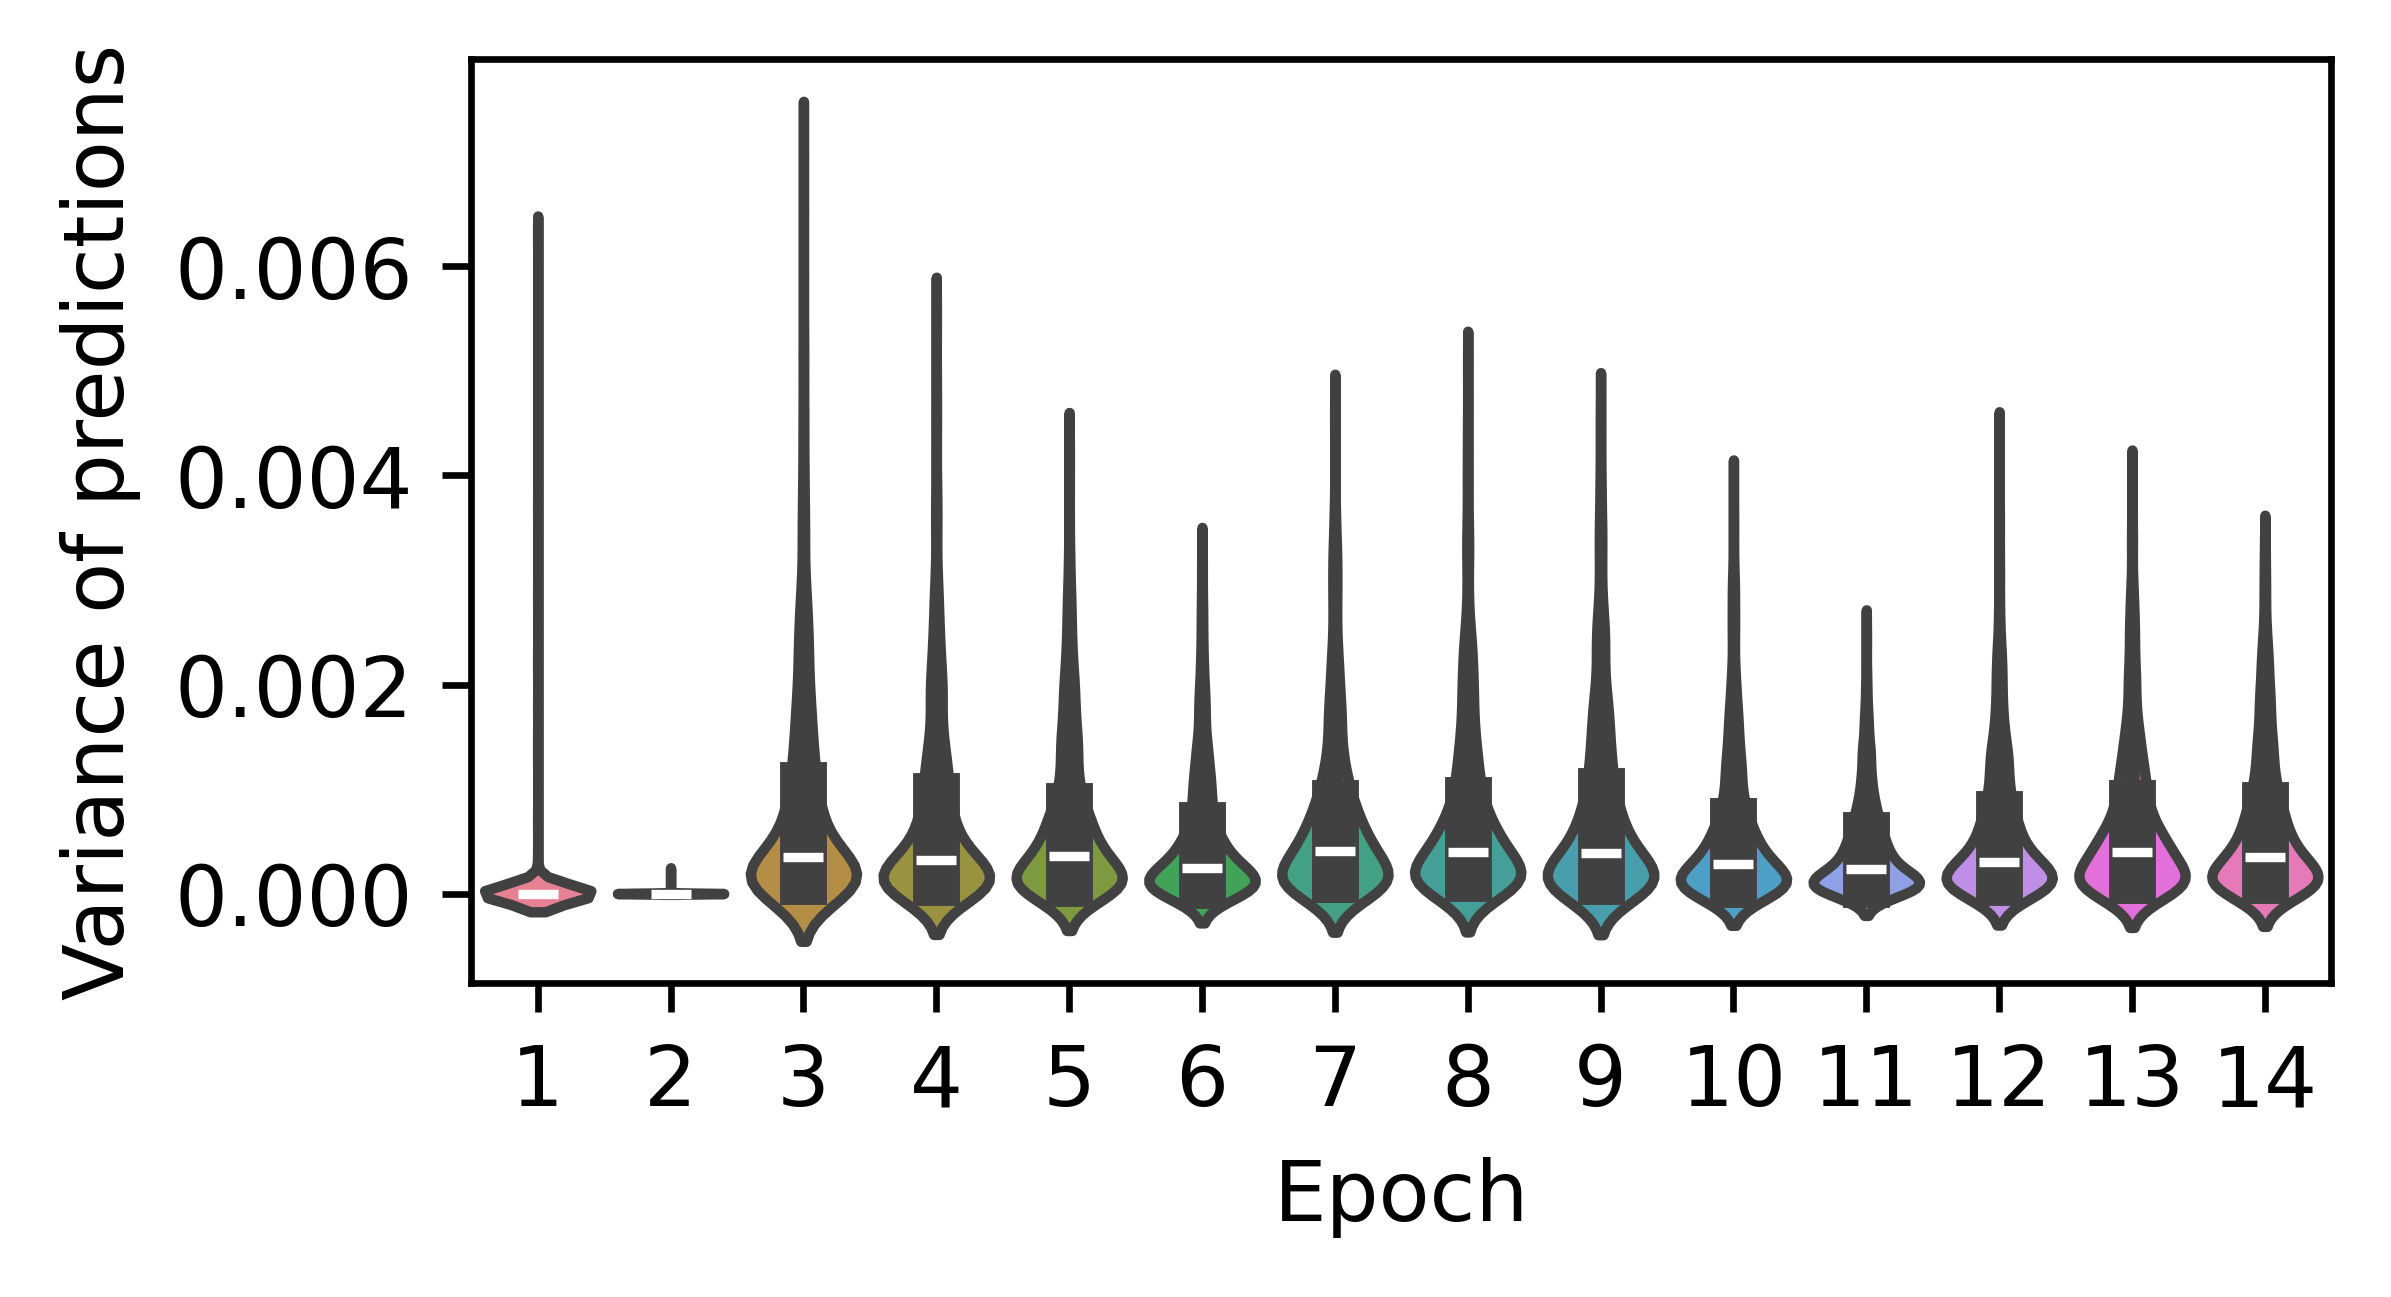

In [49]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=600)
sns.violinplot(data=[variance_distribution_dict[epoch] for epoch in epochs], ax=ax)
ax.set_xticklabels(epochs)
#ax.set_title("Variance of EMD Predictions Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Variance of predictions")
